In [17]:
import os
import pandas as pd
original = pd.read_csv("labeled_data_10032026.csv")
augmented = pd.read_csv("reviews_augmented_20260312_211931.csv")
df_aug = augmented.rename(columns={"augmented":"text"})

df= pd.concat([df_original, df_aug])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9260 entries, 0 to 593
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   rating      8666 non-null   object 
 1   text        9260 non-null   object 
 2   word_count  8666 non-null   float64
 3   food        9260 non-null   int64  
 4   service     9260 non-null   int64  
 5   place       9260 non-null   int64  
 6   cost        9260 non-null   int64  
 7   original    594 non-null    object 
dtypes: float64(1), int64(4), object(3)
memory usage: 651.1+ KB


count    9260.000000
mean       33.820410
std        44.459209
min         1.000000
25%        11.000000
50%        20.000000
75%        38.000000
max       772.000000
Name: word_count, dtype: float64


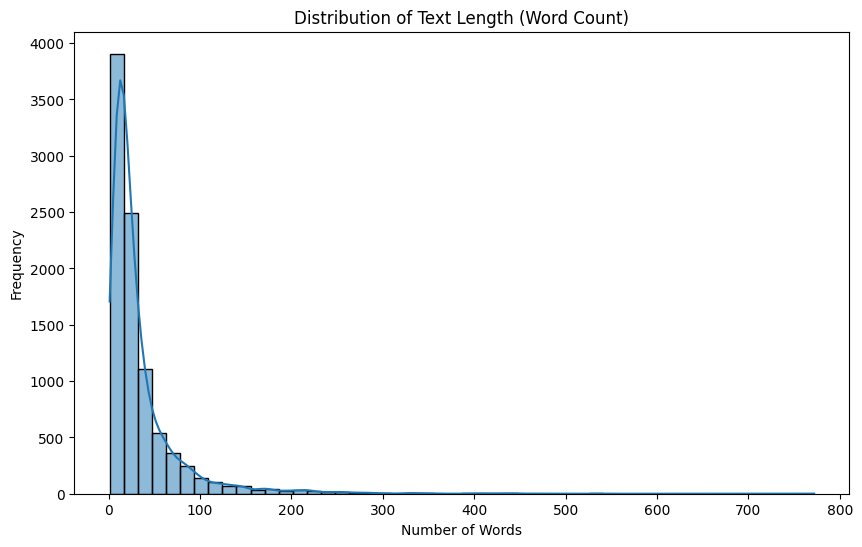

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create word count column
df["word_count"] = df["text"].astype(str).apply(lambda x: len(x.split()))

# Basic statistics (optional but useful)
print(df["word_count"].describe())

# Plot histogram
plt.figure(figsize=(10,6))
sns.histplot(df["word_count"], bins=50, kde=True)

plt.title("Distribution of Text Length (Word Count)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

Word Count Statistics:
count    9260.000000
mean       33.820410
std        44.459209
min         1.000000
25%        11.000000
50%        20.000000
75%        38.000000
max       772.000000
Name: word_count, dtype: float64


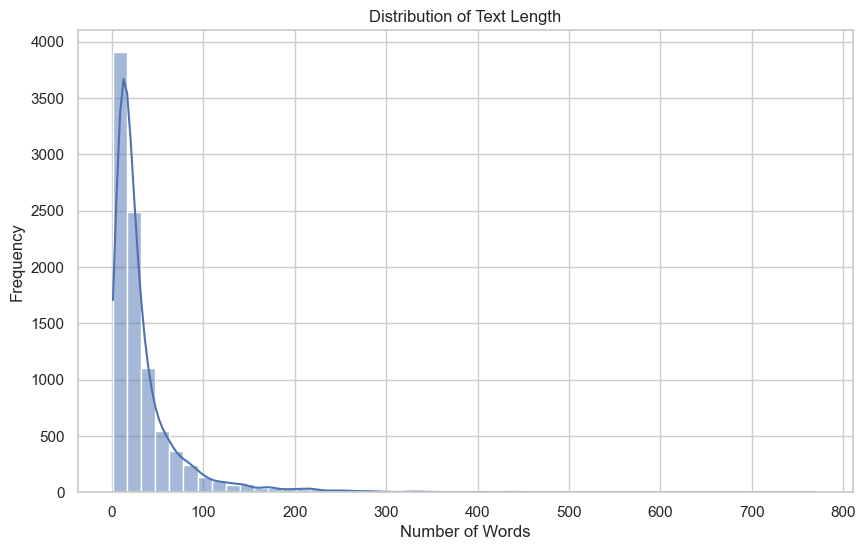


Coverage by Word Limit:
   limit   coverage
0     20  51.641469
1     30  67.969762
2     40  77.019438
3     50  82.343413
4     60  86.069114
5     80  91.025918
6    100  94.222462


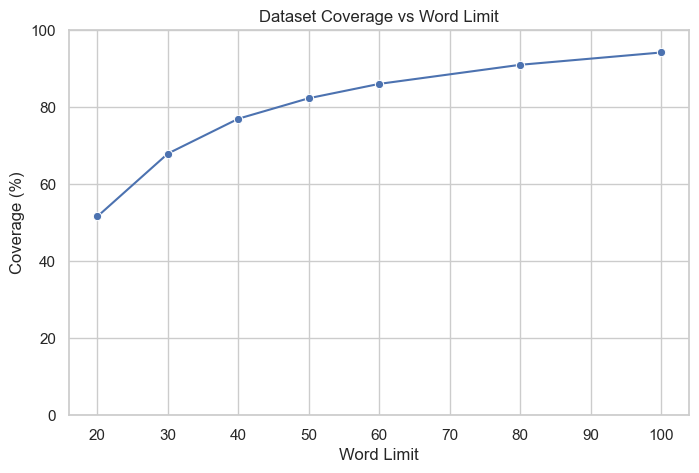


Recommended max sequence length: nan

Number of existing classes: 175


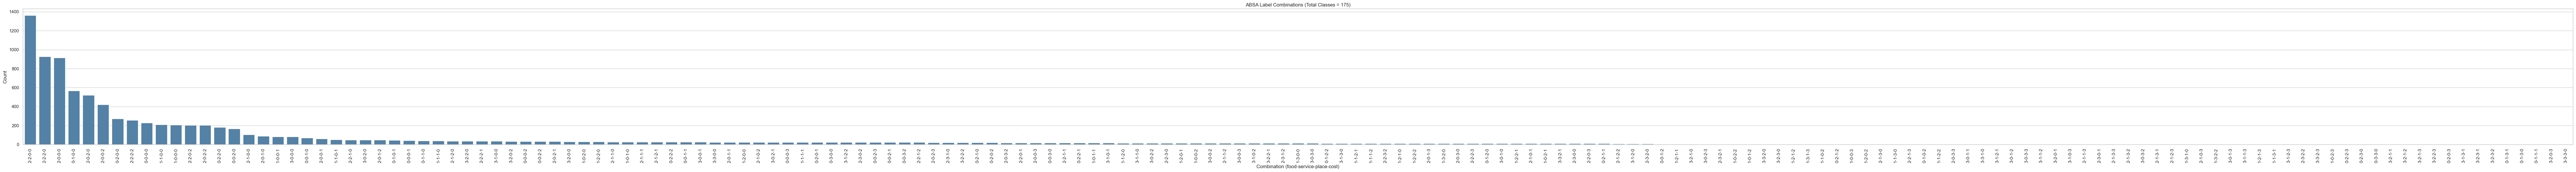

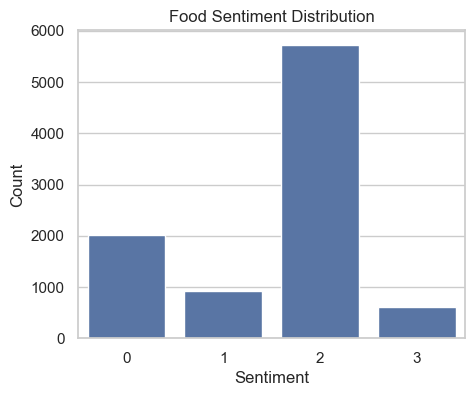

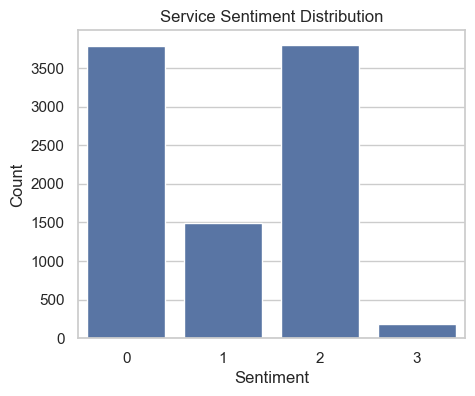

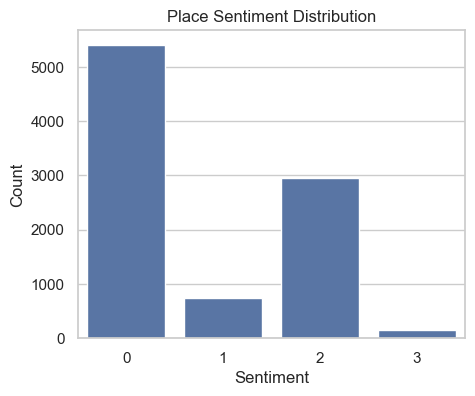

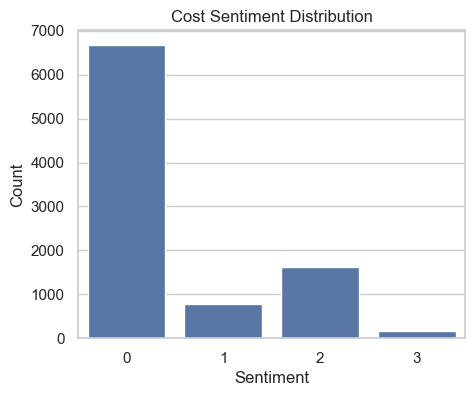

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------------
# WORD COUNT ANALYSIS
# -------------------------------

# Create word count column
df["word_count"] = df["text"].astype(str).str.split().str.len()

print("Word Count Statistics:")
print(df["word_count"].describe())

# Histogram
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="word_count", bins=50, kde=True)

plt.title("Distribution of Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()


# -------------------------------
# WORD LIMIT COVERAGE
# -------------------------------

limits = [20, 30, 40, 50, 60, 80, 100]
coverage = []

for limit in limits:
    pct = (df["word_count"] <= limit).mean() * 100
    coverage.append(pct)

coverage_df = pd.DataFrame({
    "limit": limits,
    "coverage": coverage
})

print("\nCoverage by Word Limit:")
print(coverage_df)

plt.figure(figsize=(8,5))
sns.lineplot(data=coverage_df, x="limit", y="coverage", marker="o")

plt.title("Dataset Coverage vs Word Limit")
plt.xlabel("Word Limit")
plt.ylabel("Coverage (%)")
plt.ylim(0,100)

plt.show()

best_limit = coverage_df[coverage_df["coverage"] >= 95]["limit"].min()
print("\nRecommended max sequence length:", best_limit)


# -------------------------------
# ABSA LABEL COMBINATION ANALYSIS
# -------------------------------

counts = (
    df.value_counts(subset=["food","service","place","cost"])
      .reset_index(name="count")
)

num_classes = counts.shape[0]
print("\nNumber of existing classes:", num_classes)

# Create combination label
counts["combo"] = (
    counts[["food","service","place","cost"]]
    .astype(str)
    .agg("-".join, axis=1)
)

counts = counts.sort_values("count", ascending=False)

# Dynamic width depending on number of classes
width = max(12, num_classes * 0.5)

plt.figure(figsize=(width,6))
sns.barplot(data=counts, x="combo", y="count", color="steelblue")

plt.xticks(rotation=90)
plt.xlabel("Combination (food-service-place-cost)")
plt.ylabel("Count")
plt.title(f"ABSA Label Combinations (Total Classes = {num_classes})")

plt.tight_layout()
plt.show()


# -------------------------------
# INDIVIDUAL ASPECT DISTRIBUTION
# -------------------------------

aspects = ["food","service","place","cost"]

for aspect in aspects:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df, x=aspect)

    plt.title(f"{aspect.capitalize()} Sentiment Distribution")
    plt.xlabel("Sentiment")
    plt.ylabel("Count")

    plt.show()

Best threshold: 88


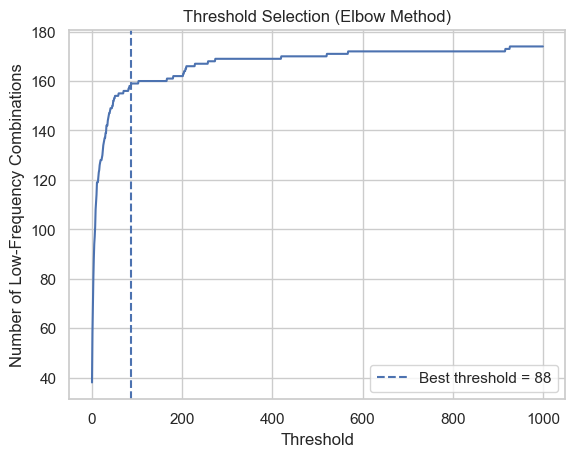

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Count combinations
counts = (
    df.value_counts(subset=["food","service","place","cost"])
      .reset_index(name="count")
)

thresholds = np.arange(1, 1000)

low_freq_counts = []
for t in thresholds:
    low_freq_counts.append((counts["count"] <= t).sum())

low_freq_counts = np.array(low_freq_counts)

# Normalize for knee detection
x = (thresholds - thresholds.min()) / (thresholds.max() - thresholds.min())
y = (low_freq_counts - low_freq_counts.min()) / (low_freq_counts.max() - low_freq_counts.min())

# Distance from diagonal line
distances = y - x
best_idx = np.argmax(distances)
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

# Plot
plt.figure()
plt.plot(thresholds, low_freq_counts)
plt.axvline(best_threshold, linestyle="--", label=f"Best threshold = {best_threshold}")
plt.xlabel("Threshold")
plt.ylabel("Number of Low-Frequency Combinations")
plt.title("Threshold Selection (Elbow Method)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import pandas as pd

# Count combinations
counts = (
    df.value_counts(subset=["food", "service", "place", "cost"])
      .reset_index(name="count")
)

threshold = best_threshold

# Merge counts with original data (keeps text)
df_with_counts = df.merge(counts, on=["food", "service", "place", "cost"])

# Filter low-frequency rows
low_freq = df_with_counts[df_with_counts["count"] <= threshold]

# Sort so lowest frequency appears first
low_freq = low_freq.sort_values(by="count", ascending=True)

# Save
low_freq.to_csv("low_frequency_classes.csv", index=False)

In [ ]:
df.to_csv('labeled_data_10032026.csv', index=False)